# Variance Reduction Methods on BS-Pricing

When pricing a derivative through simulation, the price estimate 
$\hat{P} = \frac{1}{N}\sum_{i=1}^{N} P_{i}$ has a standard error:

$$\text{SE} = \sqrt{\text{Var}(\hat{P})}$$

which measures the typical magnitude of the deviation between $\hat{P}$ 
and the true price $P$. 

Since the paths are independent and each $P_{i}$ is identically distributed (as $P$)

$$\text{Var}\left(\frac{1}{N}\sum_{i=1}^{N} P_{i}\right) 
= \frac{1}{N^{2}}\sum_{i=1}^{N}\text{Var}(P_{i}) 
= \frac{\text{Var}(P)}{N}$$

Therefore 
$$SE = \sqrt{\frac{\text{Var}(P)}{N}}$$

For large $N$, the Central Limit Theorem guarantees $\hat{P}$ is 
approximately normally distributed around $P$:

$$\frac{\hat{P} - P}{\text{SE}} \xrightarrow{d} \mathcal{N}(0,1)$$

In order to get more accurate prices,  the standard error needs to be reduced.

This notebook explores several variance reduction techniques that reduce the error estimate using the example of the standard European call price.

## Black Scholes through the Formula

$C = S_{0}\Phi(d_{1}) - K\Phi(d_{2})$ is the theoretical Black Scholes Formula which can be used to verify all the simulations.

In order to test all the models, the same values need to be used across all simulations.

Here, S0=100, K=110, r=0.05, sigma=0.2, T=2 are used.

In [ ]:
import numpy as np
from scipy.stats import norm

S0, K, r, sigma, T = 100, 110, 0.05, 0.2, 2.0

# Black-Scholes exact price
d1 = (np.log(S0/K) + (r + 0.5*sigma**2)*T) / (sigma*np.sqrt(T))
d2 = d1 - sigma*np.sqrt(T)
BS = S0*norm.cdf(d1) - K*np.exp(-r*T)*norm.cdf(d2)
print(f"Black-Scholes: {BS:.6f}")




Black-Scholes: 11.455456


## Standard Monte Carlo Simulations

In order to estimate SE empirically, the standard deviation of call prices are used to determine the $\sqrt{Var(C)}$ (difference between N and N-1 is negligible for large N)

Below is the general iterative formula used to calculate a single path of the stock price:

$$S_{i\Delta t} = S_{(i-1)\Delta t}\exp((r-\frac{\sigma^{2}}{2})(\Delta t) + \sigma(\Delta t)^{1/2}Z)$$

for i=1..m where $m = \frac{T}{\Delta t}

This is repreated for all N paths.



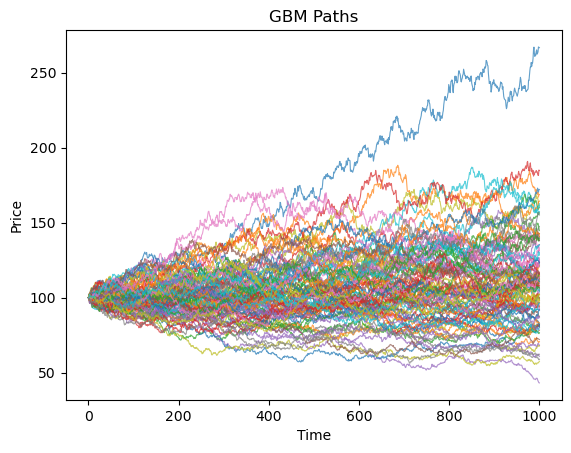

In [2]:
import matplotlib.pyplot as plt
N = 10000
m = 1000
SEED = 42
rng = np.random.default_rng(SEED)

S = np.zeros((N, m+1))
S[:, 0] = S0
dt = T/m
Z = rng.normal(0,1,(N,m))
for j in range(1, m+1):
    S[:,j] = S[:,j-1]*np.exp((r-0.5*sigma**2)*(dt)+sigma*np.sqrt(dt)*Z[:, j-1])
for i in range(0, N, 100):
    plt.plot(S[i], linewidth = 0.8, alpha = 0.7)
plt.xlabel('Time')
plt.ylabel('Price')
plt.title('GBM Paths')
plt.show()
        



After all the N paths are derived

$$C_{i}=\exp^{-rT}(S_{i,T}-K)^{+}$$

is the price estimate for each path




In [ ]:
payoffs = np.exp(-r*T)*(np.maximum(S[:,-1]-K,0))
C = payoffs.mean()
SE = payoffs.std()/np.sqrt(N)
print(f"MC price:  {C:.4f}")
print(f"Theoretical Price: {BS:.4f}")
print(f"Standard error: {SE:.4f}")

MC price:  11.4106
Theoretical Price: 11.4555
Estimation error: 0.0614


Taking logarithms simplifies the expression and makes computation easier numerically

In [ ]:
N = 10000
m = 1000
rng = np.random.default_rng(SEED)
Z = rng.normal(0, 1, (N, m))
log_increments = (r - 0.5*sigma**2)*dt + sigma*np.sqrt(dt)*Z
log_ST = np.log(S0) + log_increments.sum(axis=1)  
S_T = np.exp(log_ST)

payoffs = np.exp(-r*T) * np.maximum(S_T - K, 0)
C  = payoffs.mean()
SE = payoffs.std() / np.sqrt(N)
print(f"Actual Price Difference:  {C-BS:.4f}")
print(f"Standard error: {SE:.4f}")

MC price:  11.4106
Theoretical Price: 11.4555
Std error: 0.1941


Vary m and N for simulation purposes to see if the variance reduces.

In [ ]:
# Vary m
for m in [1, 1000, 5000, 10000]:
    for N in [10000]:
        rng = np.random.default_rng(SEED)
        Z = rng.normal(0, 1, (N, m))
        dt = T/m
        log_ST = np.log(S0) + ((r - 0.5*sigma**2)*dt + sigma*np.sqrt(dt)*Z).sum(axis=1) 
        S_T = np.exp(log_ST)

        payoffs = np.exp(-r*T) * np.maximum(S_T - K, 0)
        C  = payoffs.mean()
        SE = payoffs.std() / np.sqrt(N)
        print(f"Value of m: {m}")
        print(f"Actual Price Difference:  {C-BS:.4f}")
        print(f"Standard error: {SE:.4f}")

Value of m: 1
MC price:  11.3472
Std error: 0.1982
Value of m: 1000
MC price:  11.4106
Std error: 0.1941
Value of m: 5000
MC price:  11.4957
Std error: 0.1977
Value of m: 10000
MC price:  11.7399
Std error: 0.2010


The standard error doesn't change with m. This holds true since the stock prices moves due to independent increments.

From theory, $ln(S_{T}) = ln(S_{0}) + (r-\frac{\sigma^{2}}{2})T + \sigma \sqrt{T}Z$

Therefore, from now on, the individual paths are not required. (These individuals paths would matter in Asian option pricing)

In [ ]:
# Vary N
import pandas as pd
storage = []
for N in [10000, 100000, 1000000]:
    rng = np.random.default_rng(SEED)
    Z = rng.normal(0, 1, N)
    log_ST = np.log(S0) + ((r - 0.5*sigma**2)*T + sigma*np.sqrt(T)*Z)  
    S_T = np.exp(log_ST)

    payoffs = np.exp(-r*T) * np.maximum(S_T - K, 0)
    C  = payoffs.mean()
    SE = payoffs.std() / np.sqrt(N)
    storage.append({'N':N, 'Simulated Call Price':C, 'Actual Price Difference':C-BS, 'Error Estimate':SE})
df = pd.DataFrame(storage)
print(df)

         N  Simulated Price  Price difference  Std Error
0    10000        11.347155         -0.108301   0.198193
1   100000        11.441849         -0.013607   0.062767
2  1000000        11.461470          0.006014   0.019742


$SE \propto \frac{1}{\sqrt N}$. 

Additionally, the estimated price gets closer to the theoretical price as well (which is shown by both the estimation error and the overall standard error) suggesting that the simulation works well.

From now on N=1000000 is used as the standard.

Instead of increasing N, the error estimate can be futher reduced through other techniques.

The improvement of the models is represented by

$$ SE_{original}//SE_{new} $$

In [91]:
N = 1000000
rng = np.random.default_rng(SEED)
Z = rng.normal(0, 1, N)
log_ST = np.log(S0) + ((r - 0.5*sigma**2)*T + sigma*np.sqrt(T)*Z)  
S_T = np.exp(log_ST)

payoffs = np.exp(-r*T) * np.maximum(S_T - K, 0)
C  = payoffs.mean()
SE = payoffs.std() / np.sqrt(N)
print(f"Standard Error: {SE:.4f}")

Standard Error: 0.0197


## Antithetic 

Here, draw only N/2 independent normals but use both Z and -Z. 

$$\hat{C}_{anti} = \frac{1}{N/2}\sum_{i=1}^{N/2} \frac{f(Z_i) + f(-Z_i)}{2}$$

Z is symmetric so $\mathbb{E}[f(Z)] = \mathbb{E}[C]$ and therefore $\mathbb{E}[\hat{C}_{anti}] = \mathbb{E}[C]$

$$Var(\frac{f(Z)+f(-Z)}{2}) = \frac{Var(f(Z)) +Var(f(-Z)) + 2Cov(f(Z),f(-Z))}{4} = \frac{\sigma^2(1+\rho)}{2}$$

where $\sigma^{2} = Var(f(Z)) = Var(C)$  and  $\rho = Corr(f(Z), f(-Z))$ where $\rho<0$ for a call option since $f$ is increasing in $Z$.

Therefore 

$$Var(C_{anti}) = Var(C) (\frac{1+\rho}{N})$$

$$SE_{anti} = SE \sqrt{1+\rho}$$




In [94]:
N = 1000000
rng = np.random.default_rng(SEED)
Z = rng.normal(0, 1, N//2)
log_ST_pos = np.log(S0) + ((r - 0.5*sigma**2)*T + sigma*np.sqrt(T)*Z) 
log_ST_neg =  np.log(S0) + ((r - 0.5*sigma**2)*T + sigma*np.sqrt(T)*(-Z)) 

ST_pos = np.exp(log_ST_pos)
ST_neg = np.exp(log_ST_neg)

P_pos = np.exp(-r*T) * np.maximum(ST_pos - K, 0)
P_neg = np.exp(-r*T) * np.maximum(ST_neg - K, 0)

# antithetic estimator — average each pair then take mean
anti = (P_pos + P_neg) / 2
C_anti = anti.mean()
SE_anti = anti.std() / np.sqrt(len(anti))


print(f"MC price:  {C_anti:.4f}")
print(f"Price Difference: {(C_anti-BS):.4f}")
print(f"Standard Error: {SE_anti:.4f}")
print(f"Standard Error Improvement: {(SE/SE_anti):.4f}x")


MC price:  11.4652
Price Difference: 0.0098
Standard Error: 0.0161
Standard Error Improvement: 1.2275x


To check if the improvement matches the theory:

$$ \frac{SE}{SE(C_{anti})} = \sqrt{\frac{1}{1+\rho}}$$

In [95]:
rho = np.corrcoef(P_pos, P_neg)[0, 1]
print(rho)
print(f"Improvement: {np.sqrt(1/(1+rho))}")

-0.33693677497720487
Improvement: 1.2280683228273586


## Moment Matching

The goal of moment matching is to make sure the simulations actually match the theoretical moments.

So here since Z is being simulated, it means standardizing Z by subtracting through mean and dividing by std

In [ ]:
N = 1000000
rng = np.random.default_rng(SEED)
Z = rng.normal(0, 1, N)
z_mean = Z.mean()
z_std = Z.std()
print(f"Mean: {z_mean}, Std: {z_std}")
Z_mm = (Z-z_mean)/z_std
log_ST = np.log(S0) + ((r - 0.5*sigma**2)*T + sigma*np.sqrt(T)*Z_mm)  
S_T = np.exp(log_ST)
payoffs_mm = np.exp(-r*T) * np.maximum(S_T - K, 0)
C_mm  = payoffs_mm.mean()
SE_mm = payoffs_mm.std() / np.sqrt(N)
print(f"MC price:  {C_mm:.4f}")
print(f"Price Difference: {(C_mm-BS):.4f}")
print(f"Standard Error: {SE_mm:.4f}")
print(f"Estimated Error Improvement: {(SE/SE_mm):.4f}")

Mean: 9.750249789376471e-05, Std: 1.0004826432403187
MC price:  11.4524
Observed Price - Theoretical Price: -0.0031
Estimated Std: 0.0197
Std reduction: 1.0004


This method doesn't improve the standard deviation much since the there is very little error in the Z values as seen above from the mean and variance of Z

## Control Variate

The goal is to correct the estimation error of itself using known theoretical properties of the model. 

In this example, the mean of $S_{T}$ is used. 

The idea is as follows:

$$C_{CV} = C - \beta(S_{T}-\mathbb{E}[S_{T}])$$

$$Var(\hat{C}-\beta(S_{T}-\mathbb{E}[S_{T}])) = Var(\hat{C}) + \beta^{2}Var(S_{T}) - 2\beta Cov(\hat{C},S_{T})$$

so $\beta^{*} = \frac{Cov(\hat{C},S_{T})}{Var(S_{T})}$ is the optimal (differentiate above w.r.t $\beta$)

Therefore, $Var(C_{CV}) = Var(C)(1-\rho^{2})$ where $\rho=Corr(S_{T}, \hat{C})$

Note that estimating $\beta$ through S, and then using S itself results in some bias due to correlation. However this bias is O(1/N) so it can be ignored. 


In [103]:
rng = np.random.default_rng(SEED)
Z = rng.normal(0, 1, N)

log_ST = np.log(S0) + ((r - 0.5*sigma**2)*T + sigma*np.sqrt(T)*Z)  
S_T = np.exp(log_ST)
payoffs_cv = np.exp(-r*T) * np.maximum(S_T - K, 0)

# known mean of S_T
E_ST = S0 * np.exp(r*T)

# optimal beta 
beta = np.cov(payoffs_cv, S_T)[0,1] / np.var(S_T)
rho = np.corrcoef(payoffs_cv, S_T)[0,1]

# control variate estimator
payoffs_cv = payoffs_cv - beta*(S_T - E_ST)
C_CV = payoffs_cv.mean()
SE_CV = payoffs_cv.std()/np.sqrt(N)

print(f"MC price:  {C_CV:.4f}")
print(f"Price Difference: {(C_CV-BS):.4f}")
print(f"Standard Error: {SE_CV:.4f}")
print(f"Estimated Error Improvement: {(SE/SE_CV):.4f}x")
print(f"Beta:      {beta:.4f}")

MC price:  11.4575
Price Difference: 0.0020
Standard Error: 0.0084
Estimated Error Improvement: 2.3451x
Beta:      0.5595


Note that this reduction in Std fits the theory

$$ \frac{SE}{SE(C_{anti})} = \frac{1}{\sqrt{1-\rho^{2}}}$$

In [104]:
# note rho is calculated before
print(rho)
print(1/np.sqrt(1-rho**2))

0.9045246072412966
2.3450979068698725


## Importance Sampling

The general concept is sample the model using a different distribution. 

$$\mathbb{E}_{f}[h(Z)] = \mathbb{E}_{g}[\frac{f(Z)h(Z)}{g(Z)}]$$

and the estimator shifts from $$\hat C = \frac{\sum_{1}^{N} h(f(x))}{N}$$

to $$\hat C_{IS} = \frac{\sum_{1}^{N} h(g(x))w(g(x))}{N}$$ where $w=\frac{f}{g}$

In the examples above, the implicit expectation computed is:
$\mathbb{E}_{\phi}[f(Z)]$ where $\phi(z)$ is the standard normal pdf

and $$f(z) = \exp(-rT)max(S_{T}(Z)-k,0)^{+}$$ 
where $$S_{T}(Z) = S_{0}\exp^{(r-\frac{\sigma^{2}}{2})T+\sigma \sqrt{T}Z}$$

Note that an ideal g(x) is s.t $\frac{f(x)}{g(x)}$ is well defined (for w(x) sampling)

Therefore, g(x) should be normal i.e try g(x) is $N(\mu, 1)$

Then $w(x)=\exp(\mu x - \frac{\mu^{2}}{2})$




In [107]:
mu = 1
N = 1000000
rng = np.random.default_rng(SEED)
Z = rng.normal(0, 1, N)
Z_mu = mu+Z
w_mu = np.exp(-mu*Z_mu + mu**2/2)
log_ST = np.log(S0) + ((r - 0.5*sigma**2)*T + sigma*np.sqrt(T)*Z_mu)  
S_T = np.exp(log_ST)
payoffs_is = np.exp(-r*T) * np.maximum(S_T - K, 0)*w_mu
print(len(payoffs_is))
C_IS = payoffs_is.mean()
SE_IS = payoffs_is.std()/np.sqrt(N)

print(f"MC price:  {C_IS:.4f}")
print(f"Price Difference {(C_IS-BS):.4f}")
print(f"Standard Error: {SE_IS:.4f}")
print(f"Estimated Error Improvement: {(SE/SE_IS):.4f}")

1000000
MC price:  11.4598
Price Difference 0.0043
Standard Error: 0.0066
Estimated Error Improvement: 2.9829


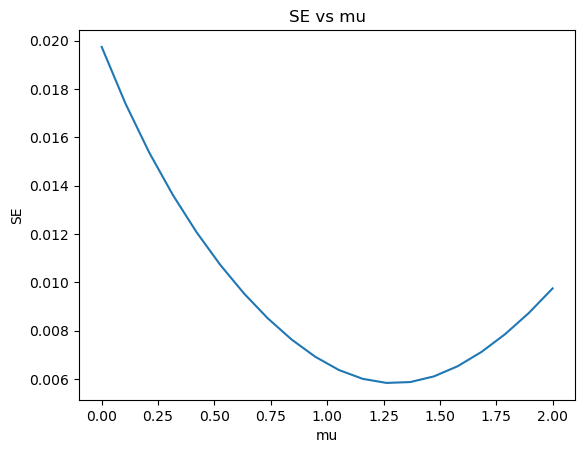

In [109]:
results = []

for mu in np.linspace(0, 2, 20):
    rng = np.random.default_rng(SEED)
    Z = rng.normal(mu, 1, N)
    w = np.exp(-mu*Z + 0.5*mu**2)
    log_ST = np.log(S0) + (r - 0.5*sigma**2)*T + sigma*np.sqrt(T)*Z
    S_T = np.exp(log_ST)
    payoffs = np.exp(-r*T) * np.maximum(S_T - K, 0) * w
    results.append((mu, payoffs.mean(), payoffs.std()/np.sqrt(N)))

results = np.array(results)
plt.plot(results[:,0], results[:,2])
plt.xlabel('mu')
plt.ylabel('SE')
plt.title('SE vs mu')
plt.show()

In [115]:
mu = 1.25
N = 1000000
rng = np.random.default_rng(SEED)
Z = rng.normal(mu, 1, N)
w = np.exp(-mu*Z + 0.5*mu**2)
log_ST = np.log(S0) + (r - 0.5*sigma**2)*T + sigma*np.sqrt(T)*Z
S_T = np.exp(log_ST)
payoffs_is = np.exp(-r*T) * np.maximum(S_T - K, 0) * w
C_IS = payoffs_is.mean()
SE_IS = payoffs_is.std()/np.sqrt(N)
print(f"Mu: {mu}")
print(f"MC price:  {C_IS:.4f}")
print(f"Price Difference {(C_IS-BS):.4f}")
print(f"Standard Error: {SE_IS:.4f}")
print(f"Estimated Error Improvement: {(SE/SE_IS):.4f}")

Mu: 1.25
MC price:  11.4601
Price Difference 0.0047
Standard Error: 0.0058
Estimated Error Improvement: 3.3789


Unlike the previous estimators, there is no clear theoretical test for the standard error. 

Therefore this method needs to be tested empirically using the knowledge of CLT.

This can be done by repeating this test several times, finding the actual error and checking if the actual error matches the expected error distribution (N(0, SE)).

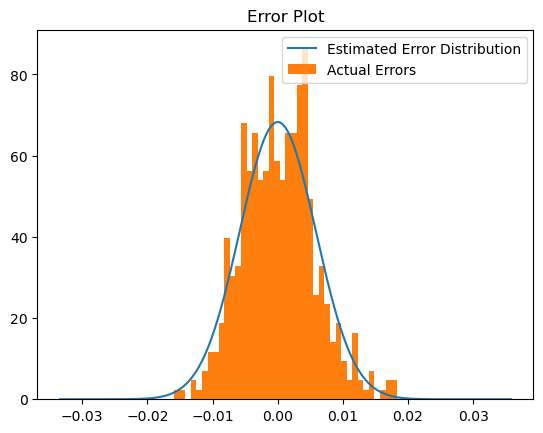

Empirical std of errors: 0.0056
Estimated SE: 0.0058


In [118]:
N = 1000000
k = 500
mu = 1.25
actual_error = np.zeros(k)
for trial in range(k):
    rng = np.random.default_rng(trial)
    Z = rng.normal(mu, 1, N)
    w = np.exp(-mu*Z + 0.5*mu**2)
    log_ST = np.log(S0) + (r - 0.5*sigma**2)*T + sigma*np.sqrt(T)*Z
    S_T = np.exp(log_ST)
    payoffs_is = np.exp(-r*T) * np.maximum(S_T - K, 0) * w
    C_IS = payoffs_is.mean()
    actual_error[trial] = C_IS-BS
    if trial==0:
        SE_IS = payoffs_is.std()/np.sqrt(N)
x = np.linspace(actual_error.min() - 3*SE_IS,
            actual_error.max() + 3*SE_IS, 300)
pdf = norm.pdf(x, loc=0, scale=SE_IS)
plt.figure()
plt.plot(x, pdf, label='Estimated Error Distribution')
plt.hist(actual_error, bins = 40, label='Actual Errors', density=True)
plt.title(f"Error Plot")
plt.legend()
plt.show()
print(f"Empirical std of errors: {actual_error.std():.4f}")
print(f"Estimated SE: {SE_IS:.4f}")


Based on the graph, the method gives a fairly reliable estimate of the SE.

## Low Discrepency Sequences 

Instead of random variable generation, use evenly spaced deterministic samples. 

In this example, evenly spaced quantiles of Z are used.

Note that since Z is being chosen deterministically, the samples are not i.i.d random. 

Therefore, a different approach needs to be used here.

First generate m random shift parameters. 

For each shift, generate \frac{N}{m} deterministic Z samples and then calculate the mean value of C.

As each shift is independent, the standard method for estimation error can then be used.

Note this test is a fair comparison, since only N stock prices are computed like the other methods


In [110]:
m = 200
N = 1000000
s = N//m
estimates_LD = np.zeros(m)

for seed in range(m):
    rng = np.random.default_rng(seed)
    # random shift
    i = np.arange(1, s+1)
    shift = rng.uniform(0, 1)      
    # generate the deterministic samples for each shift      
    U = ((i - 0.5)/s + shift) % 1.0     
    Z = norm.ppf(U)
    S_T = S0 * np.exp((r - 0.5*sigma**2)*T + sigma*np.sqrt(T)*Z)
    payoffs_LD = np.exp(-r*T) * np.maximum(S_T - K, 0)
    estimates_LD[seed] = payoffs_LD.mean()

C_LD = estimates_LD.mean()
SE_LD = estimates_LD.std()/np.sqrt(m)
print(f"MC price:  {C_LD:.4f}")
print(f"Price Difference: {(C_LD-BS):.4f}")
print(f"Standard Error: {SE_LD:.4f}")
print(f"Estimated Error Improvement: {(SE/SE_LD):.4f}x")

MC price:  11.4564
Price Difference: 0.0009
Standard Error: 0.0009
Estimated Error Improvement: 21.5727x


Similar to Importance Sampling, this method needs to be tested empirically. 

Note that the value of SE derived earlier on for all the simulations

In [ ]:
m = 200
N = 1000000
k = 500
s = N//m
actual_error = np.zeros(k)
for trial in range(k):
    estimates_LD = np.zeros(m)
    for seed in range(m):
        rng = np.random.default_rng(seed+trial*m)
        i = np.arange(1, s+1)
        shift = rng.uniform(0, 1)           
        U = ((i - 0.5)/s + shift) % 1.0     
        Z = norm.ppf(U)
        S_T = S0 * np.exp((r - 0.5*sigma**2)*T + sigma*np.sqrt(T)*Z)
        payoffs_LD = np.exp(-r*T) * np.maximum(S_T - K, 0)
        estimates_LD[seed] = payoffs_LD.mean()
    actual_error[trial] = estimates_LD.mean()-BS








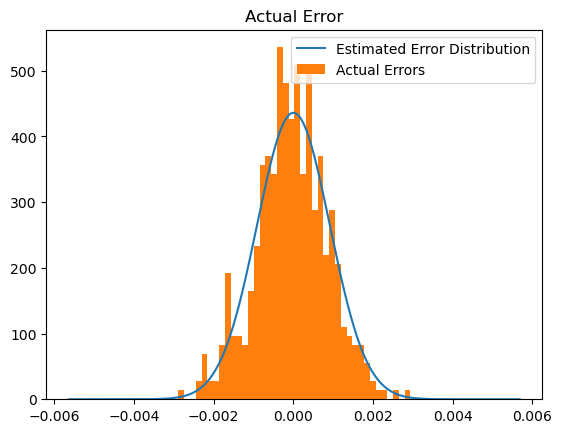

In [ ]:
x = np.linspace(actual_error.min() - 3*SE_LD,
                actual_error.max() + 3*SE_LD, 300)
pdf = norm.pdf(x, loc=0, scale=SE_LD)
plt.plot(x, pdf, label='Estimated Error Distribution')
plt.hist(actual_error, bins = 40, label='Actual Errors', density=True)
plt.title("Actual Error")
plt.xlabel('Error')
plt.ylabel('Density')
plt.legend()
plt.show()

In [ ]:
print(f"Empirical std of errors: {actual_error.std():.6f}")
print(f"Estimated SE: {SE_LD:.6f}")


Empirical std of errors: 0.000894
Mean estimated SE:       0.000915
Ratio:                   0.9773  (target 1.0)


Based on the graph,  the method gives a fairly reliable estimate of the SE.

Note that the test above checked for m=200.
Now that the method is verified to work, it makes sense to check different values of m.

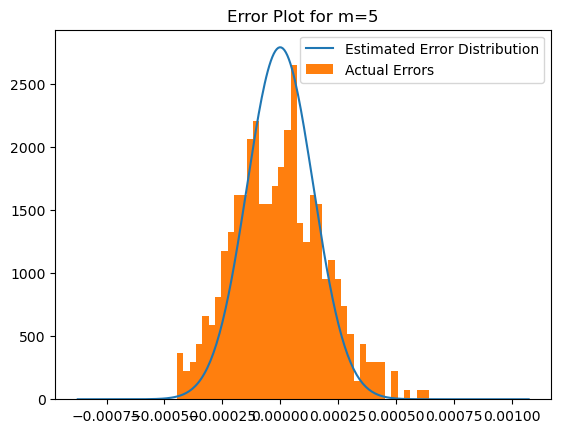

Empirical std of errors: 0.000195
Estimated SE: 0.000143


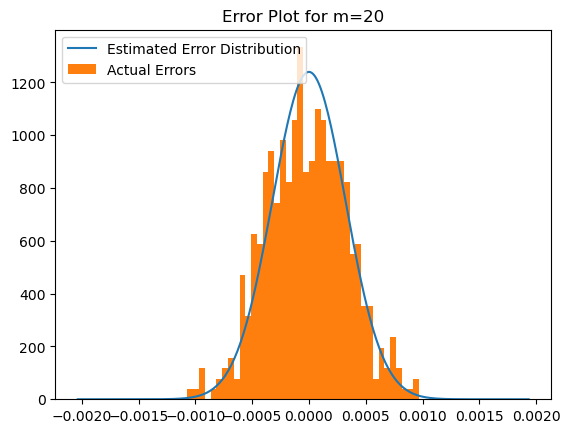

Empirical std of errors: 0.000355
Estimated SE: 0.000322


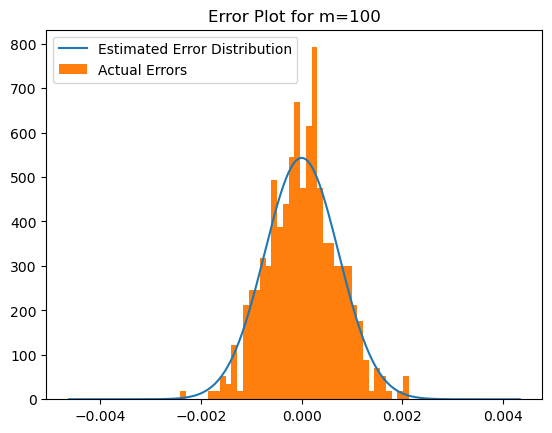

Empirical std of errors: 0.000690
Estimated SE: 0.000735


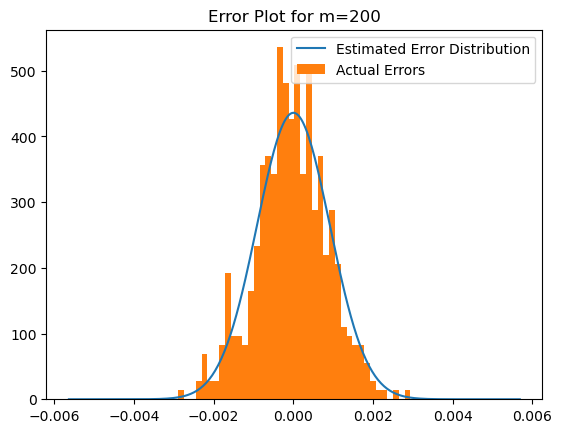

Empirical std of errors: 0.000894
Estimated SE: 0.000915


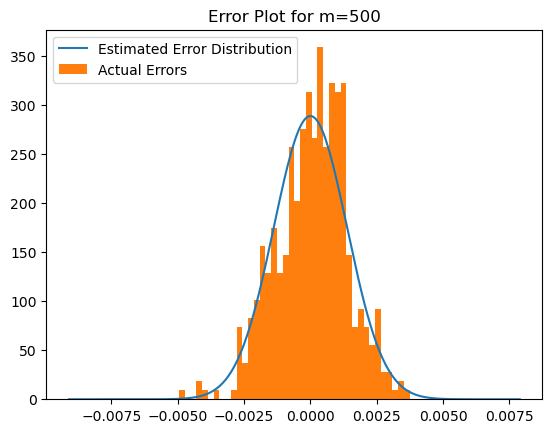

Empirical std of errors: 0.001342
Estimated SE: 0.001382


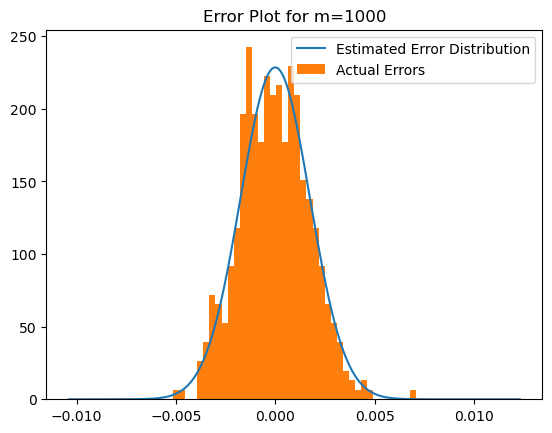

Empirical std of errors: 0.001722
Estimated SE: 0.001746
      m        SE  empirical_std  Actual Error Std/SE
0     5  0.000143       0.000195             1.360096
1    20  0.000322       0.000355             1.103084
2   100  0.000735       0.000690             0.938738
3   200  0.000915       0.000894             0.977342
4   500  0.001382       0.001342             0.971242
5  1000  0.001746       0.001722             0.986078


In [119]:
storage = []
for m in [5, 20, 100, 200, 500, 1000]:
    N = 1000000
    k = 500
    s = N//m
    actual_error = np.zeros(k)
    for trial in range(k):
        estimates_LD = np.zeros(m)
        for seed in range(m):
            rng = np.random.default_rng(seed+trial*m)
            i = np.arange(1, s+1)
            shift = rng.uniform(0, 1)            
            U = ((i - 0.5)/s + shift) % 1.0     
            Z = norm.ppf(U)
            S_T = S0 * np.exp((r - 0.5*sigma**2)*T + sigma*np.sqrt(T)*Z)
            payoffs_LD = np.exp(-r*T) * np.maximum(S_T - K, 0)
            estimates_LD[seed] = payoffs_LD.mean()
        actual_error[trial] = estimates_LD.mean()-BS
        if trial==0:
            SE_LD = estimates_LD.std()/np.sqrt(m)
    storage.append({'m':m, 'SE':SE_LD, 'empirical_std':actual_error.std(), 'Actual Error Std/SE':actual_error.std()/SE_LD})
    x = np.linspace(actual_error.min() - 3*SE_LD,
                actual_error.max() + 3*SE_LD, 300)
    pdf = norm.pdf(x, loc=0, scale=SE_LD)
    plt.figure()
    plt.plot(x, pdf, label='Estimated Error Distribution')
    plt.hist(actual_error, bins = 40, label='Actual Errors', density=True)
    plt.title(f"Error Plot for m={m}")
    plt.legend()
    plt.show()
    print(f"Empirical std of errors: {actual_error.std():.6f}")
    print(f"Estimated SE: {SE_LD:.6f}")
df = pd.DataFrame(storage)
print(df)

Interestingly, as m increases the estimated SE increases (i.e the technique is less effective at reducing standard error) but the error estimates SE are closer to the empirical std and therefore more reliable.

